<a href="https://colab.research.google.com/github/atharvam505-blip/userforecast/blob/main/TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generate Python code for Google Colab that mounts Google Drive, installs required libraries (pandas, numpy, matplotlib, seaborn, statsmodels, scikit-learn, pmdarima), loads the CSV file from '/content/drive/MyDrive/time_series_master_data/minimal_time_series.csv' into a DataFrame, converts the date column to datetime, sets it as index, sorts the data, and prints shape and head.


In [ ]:
# Install required libraries silently
!pip -q install pandas numpy matplotlib seaborn statsmodels scikit-learn pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
import pmdarima as pm

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the file path
FILE_PATH = '/content/drive/MyDrive/Campus_Courses/Foundation of Business Analytics/time_series_master_data/minimal_time_series.csv'

# Load the CSV file into a DataFrame
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Successfully loaded data from {FILE_PATH}")
except FileNotFoundError:
    print(f"Error: The file {FILE_PATH} was not found. Please ensure it exists and Drive is mounted correctly.")
    # Instead of exit(), re-raise the error to stop cell execution immediately in Colab
    raise FileNotFoundError(f"The file {FILE_PATH} was not found. Please ensure it exists and Drive is mounted correctly.")

# Convert 'date' column to datetime and set as index
# This part of the code will only be reached if the file was loaded successfully
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Sort the DataFrame by index
df.sort_index(inplace=True)

# Print shape and head of the DataFrame
print(f"\nDataFrame Shape: {df.shape}")
print("\nDataFrame Head:")
print(df.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.9 MB/s eta 0:00:00
Mounted at /content/drive
Successfully loaded data from /content/drive/MyDrive/Campus_Courses/Foundation of Business Analytics/time_series_master_data/minimal_time_series.csv

DataFrame Shape: (2922, 1)

DataFrame Head:
            daily_business_metric
date                             
2018-01-01                    207
2018-01-02                    209
2018-01-03                    214
2018-01-04                    216
2018-01-05                    215


Generate Python code for Google Colab that creates a clean line plot of the daily_business_metric time series using matplotlib with proper title, labels, grid, and figure size.


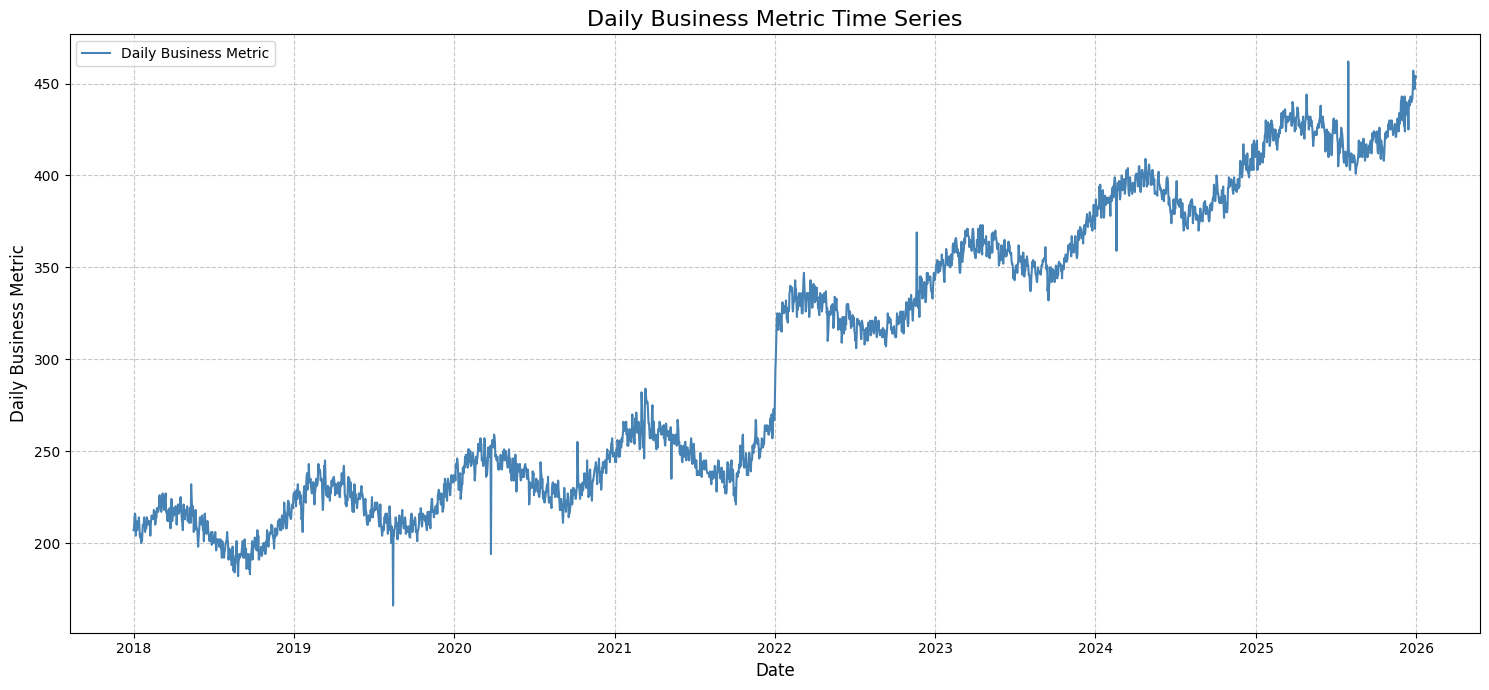

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['daily_business_metric'], label='Daily Business Metric', color='steelblue')
plt.title('Daily Business Metric Time Series', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Business Metric', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Generate Python code for Google Colab that resamples the series into weekly and monthly frequency using mean aggregation and plots daily, weekly, and monthly series together.


/tmp/ipykernel_1073/1877039884.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df['daily_business_metric'].resample('M').mean()


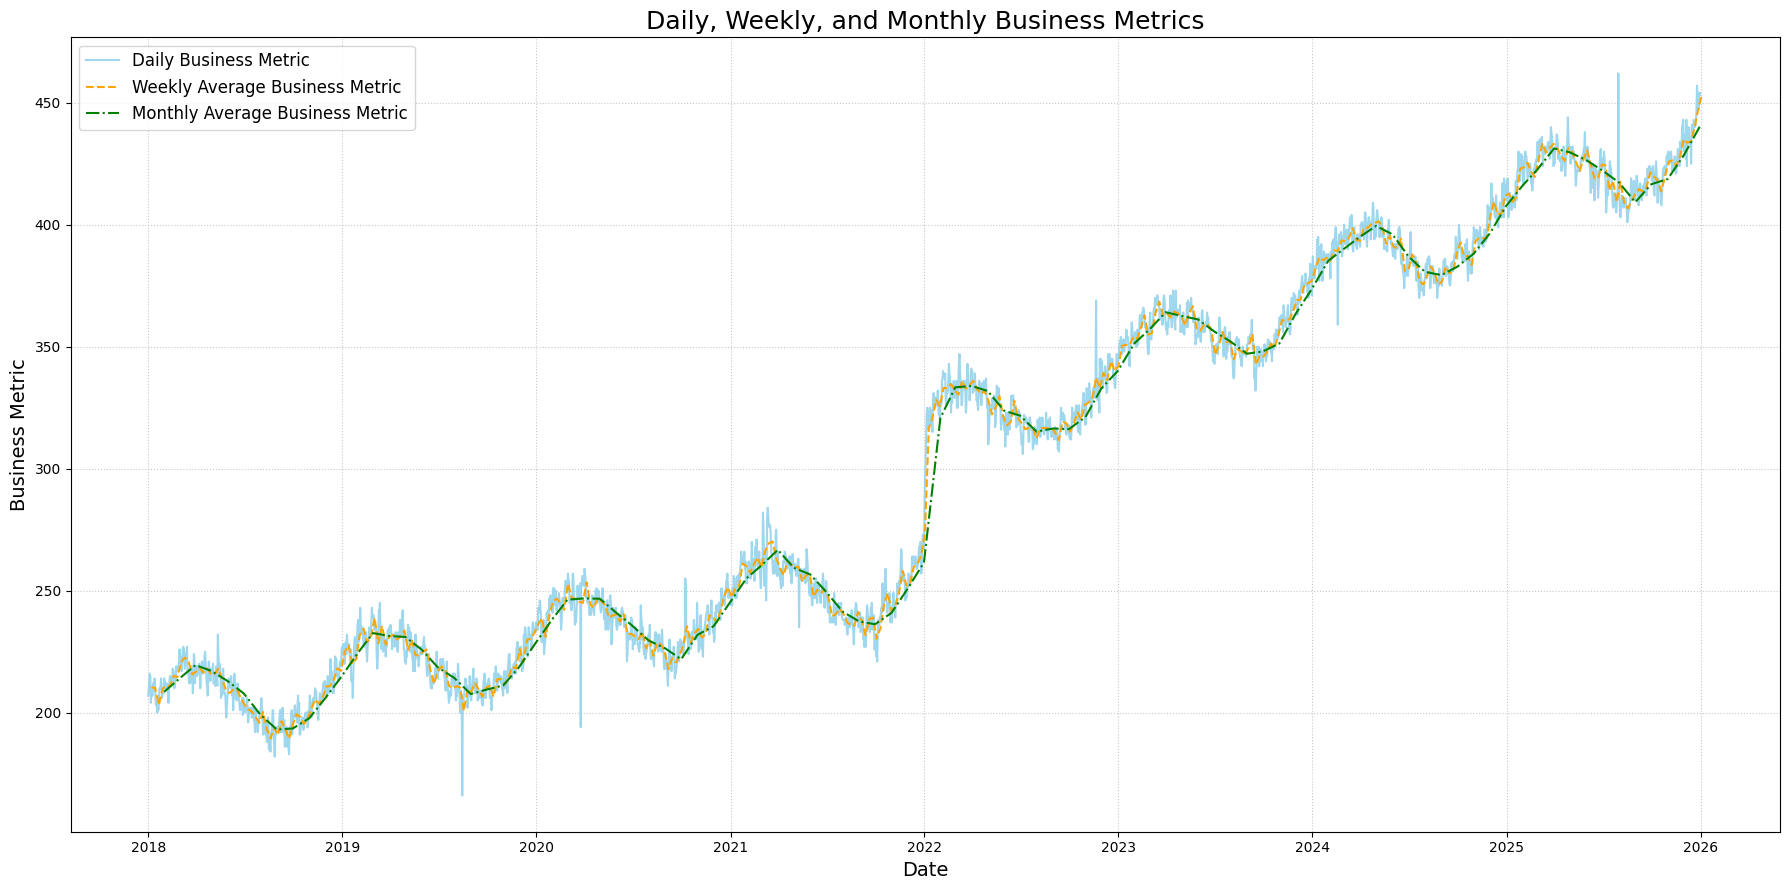

In [ ]:
# Resample to weekly frequency using mean aggregation
df_weekly = df['daily_business_metric'].resample('W').mean()

# Resample to monthly frequency using mean aggregation
df_monthly = df['daily_business_metric'].resample('M').mean()

# Plotting all three series together
plt.figure(figsize=(18, 9))

plt.plot(df.index, df['daily_business_metric'], label='Daily Business Metric', color='skyblue', alpha=0.8)
plt.plot(df_weekly.index, df_weekly, label='Weekly Average Business Metric', color='orange', linestyle='--')
plt.plot(df_monthly.index, df_monthly, label='Monthly Average Business Metric', color='green', linestyle='-.')

plt.title('Daily, Weekly, and Monthly Business Metrics', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Business Metric', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

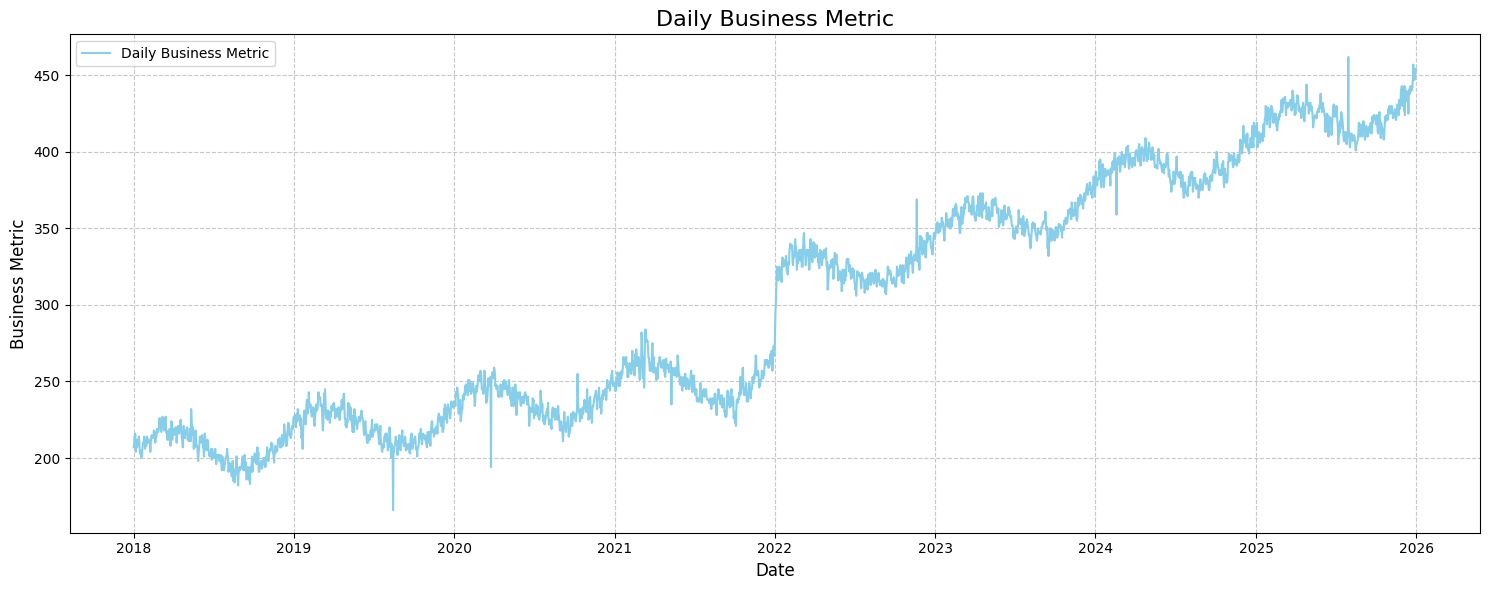

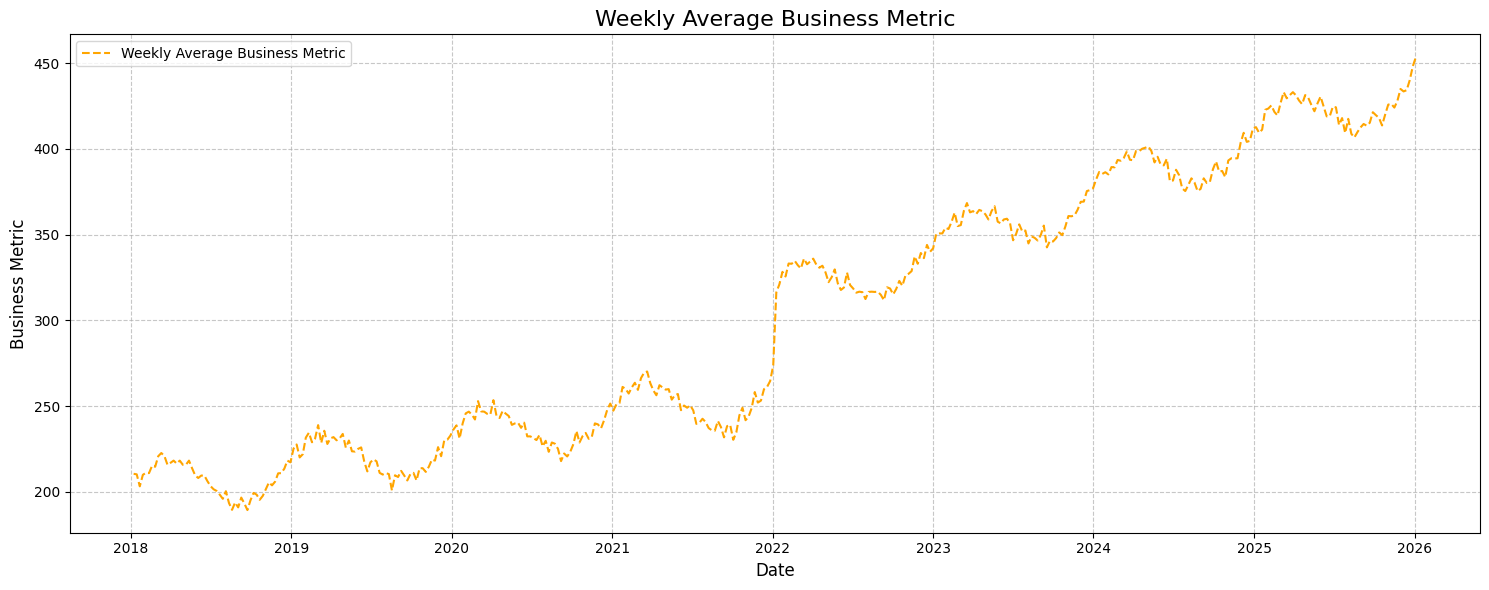

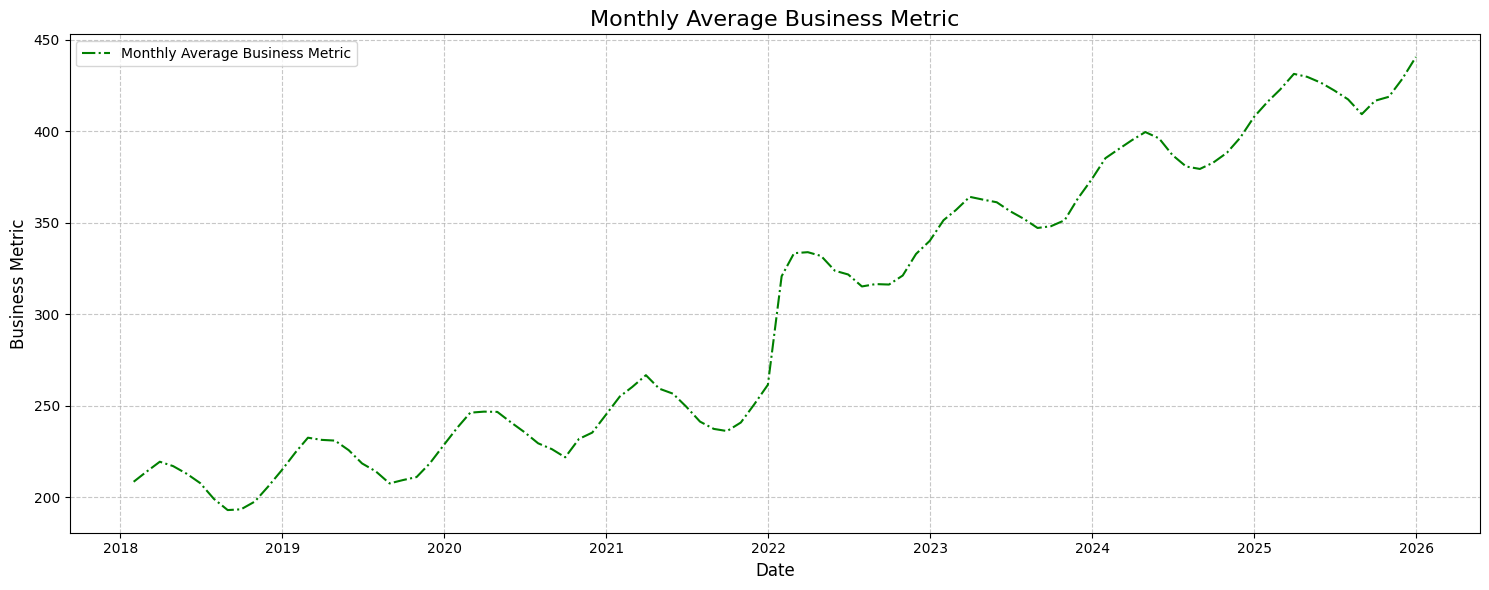

In [ ]:
# Plot Daily Business Metric
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['daily_business_metric'], label='Daily Business Metric', color='skyblue')
plt.title('Daily Business Metric', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Business Metric', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Weekly Average Business Metric
plt.figure(figsize=(15, 6))
plt.plot(df_weekly.index, df_weekly, label='Weekly Average Business Metric', color='orange', linestyle='--')
plt.title('Weekly Average Business Metric', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Business Metric', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Monthly Average Business Metric
plt.figure(figsize=(15, 6))
plt.plot(df_monthly.index, df_monthly, label='Monthly Average Business Metric', color='green', linestyle='-.')
plt.title('Monthly Average Business Metric', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Business Metric', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Generate Python code for Google Colab that creates new time-based features from the datetime index including year, quarter, month, week, day, day_of_week, day_of_year, is_weekend, and displays the updated DataFrame.


In [ ]:
# Create new time-based features from the datetime index
df['year'] = df.index.year
df['quarter'] = df.index.quarter
df['month'] = df.index.month
df['week'] = df.index.isocalendar().week.astype(int) # .isocalendar().week for week number
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek # Monday=0, Sunday=6
df['day_of_year'] = df.index.dayofyear
df['is_weekend'] = ((df.index.dayofweek == 5) | (df.index.dayofweek == 6)).astype(int)

# Display the updated DataFrame
print("Updated DataFrame with new time-based features:")
print(df.head())

Updated DataFrame with new time-based features:
            daily_business_metric  year  quarter  month  week  day  \
date                                                                 
2018-01-01                    207  2018        1      1     1    1   
2018-01-02                    209  2018        1      1     1    2   
2018-01-03                    214  2018        1      1     1    3   
2018-01-04                    216  2018        1      1     1    4   
2018-01-05                    215  2018        1      1     1    5   

            day_of_week  day_of_year  is_weekend  
date                                              
2018-01-01            0            1           0  
2018-01-02            1            2           0  
2018-01-03            2            3           0  
2018-01-04            3            4           0  
2018-01-05            4            5           0  


Generate Python code for Google Colab that groups the data by day_of_week and month to compute mean values and plots corresponding bar charts.


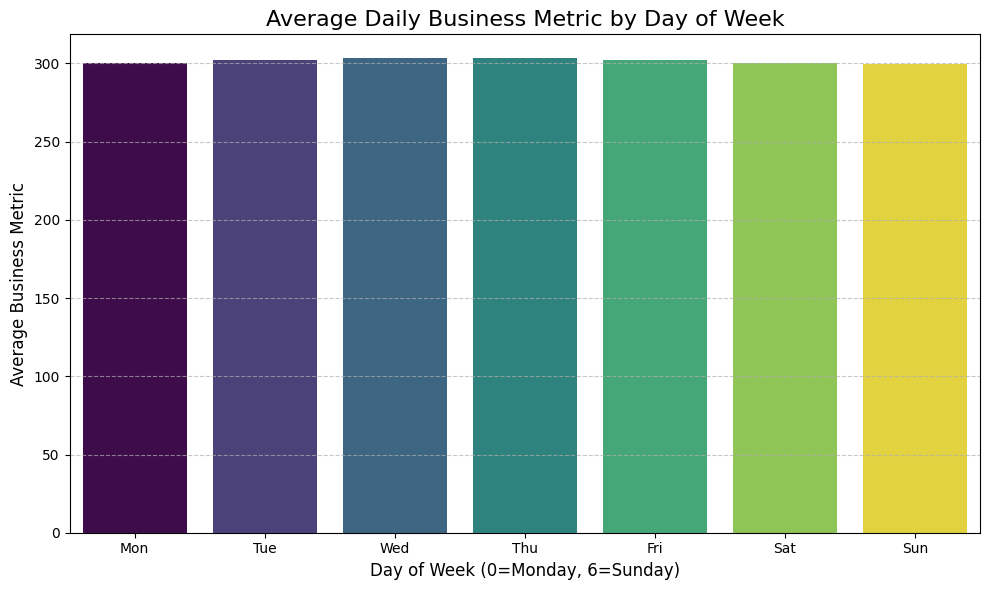

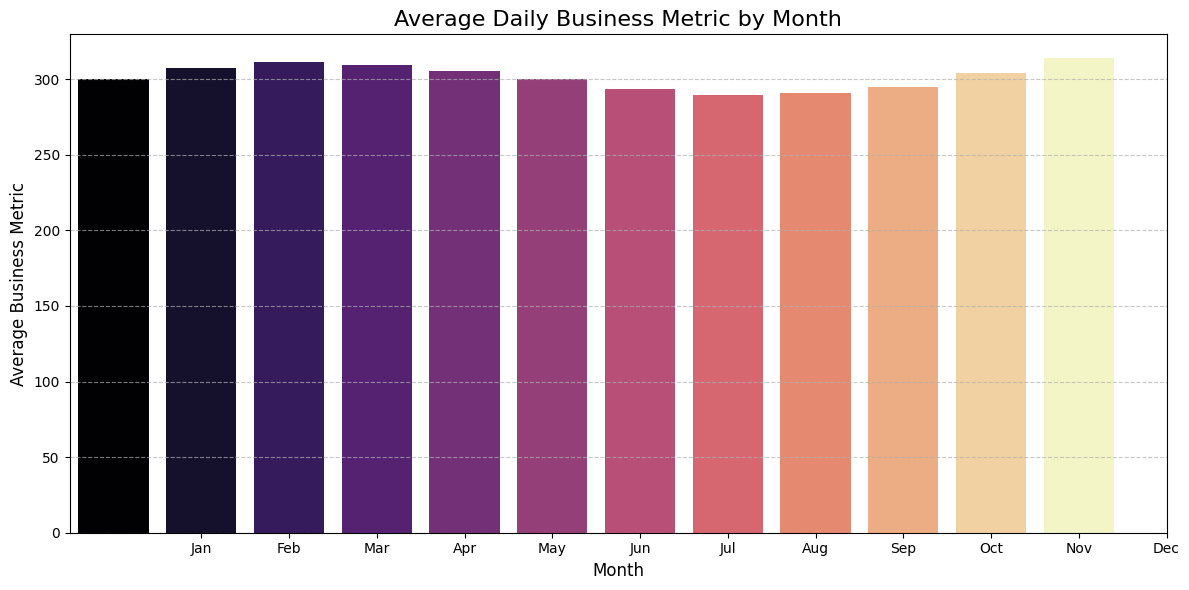

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by day_of_week and compute mean daily_business_metric
df_dayofweek_mean = df.groupby('day_of_week')['daily_business_metric'].mean()

# Plotting by day_of_week
plt.figure(figsize=(10, 6))
sns.barplot(x=df_dayofweek_mean.index, y=df_dayofweek_mean.values, hue=df_dayofweek_mean.index, palette='viridis', legend=False)
plt.title('Average Daily Business Metric by Day of Week', fontsize=16)
plt.xlabel('Day of Week (0=Monday, 6=Sunday)', fontsize=12)
plt.ylabel('Average Business Metric', fontsize=12)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Group by month and compute mean daily_business_metric
df_month_mean = df.groupby('month')['daily_business_metric'].mean()

# Plotting by month
plt.figure(figsize=(12, 6))
sns.barplot(x=df_month_mean.index, y=df_month_mean.values, hue=df_month_mean.index, palette='magma', legend=False)
plt.title('Average Daily Business Metric by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Business Metric', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Generate Python code for Google Colab that performs additive and multiplicative seasonal decomposition using statsmodels with an appropriate period and plots trend, seasonal, and residual components.


Performing Additive Seasonal Decomposition with monthly period...


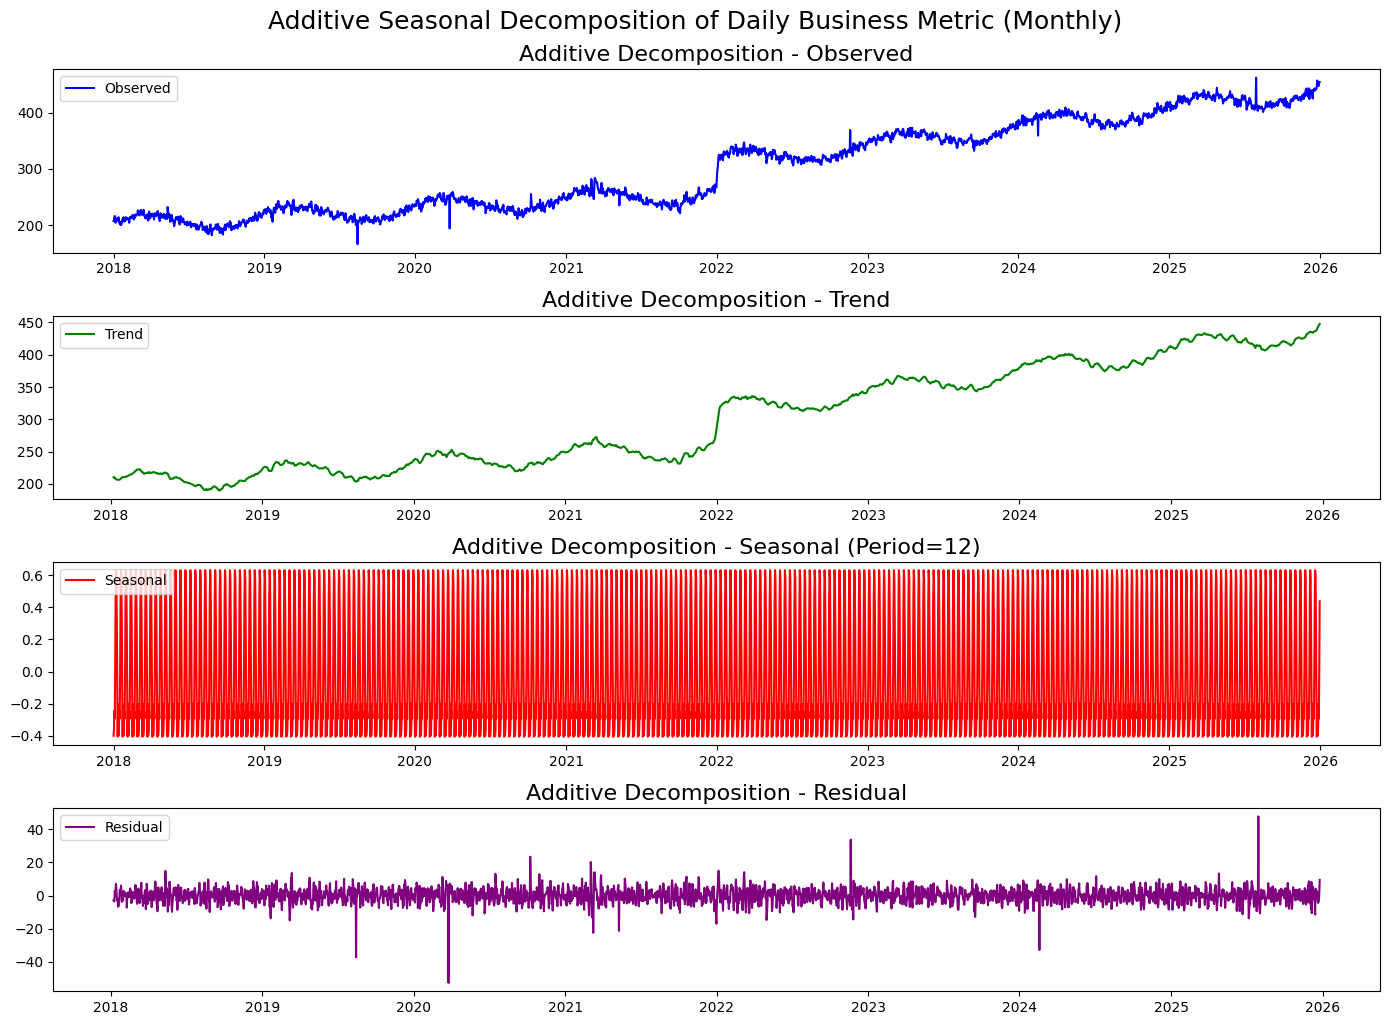


Performing Multiplicative Seasonal Decomposition with monthly period...


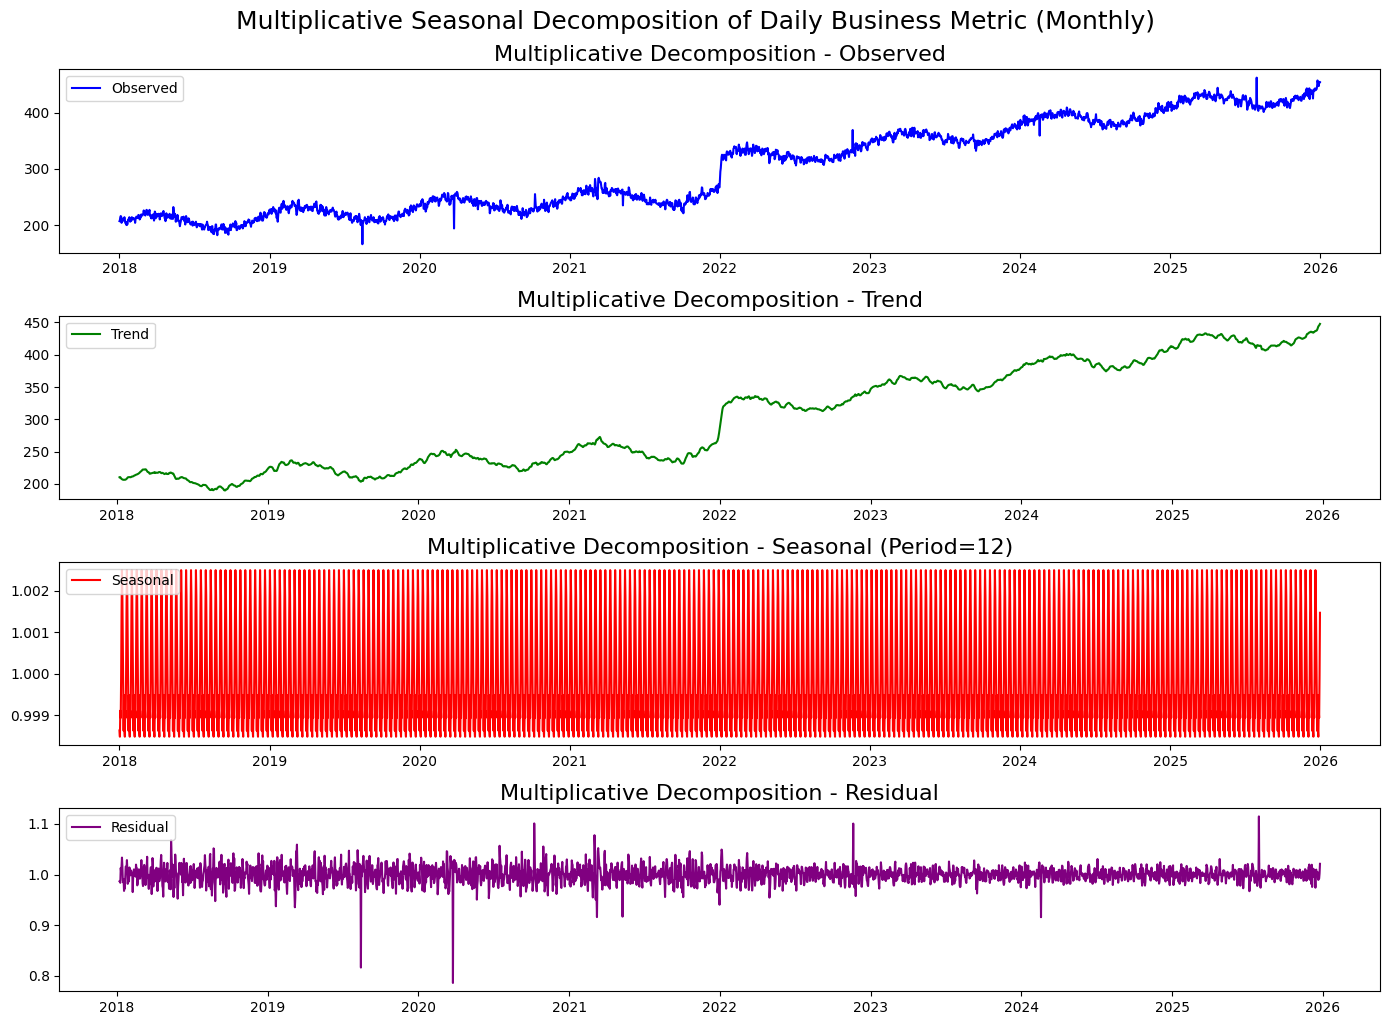

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with 'daily_business_metric' as the time series
# And the index is a datetime index. A period of 12 is chosen for monthly seasonality.

# Additive Decomposition
print("Performing Additive Seasonal Decomposition with monthly period...")
additive_decomposition = seasonal_decompose(df['daily_business_metric'], model='additive', period=12)

# Plotting Additive Decomposition components
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(additive_decomposition.observed, label='Observed', color='blue')
plt.title('Additive Decomposition - Observed', fontsize=16)
plt.legend(loc='upper left')

plt.subplot(4, 1, 2)
plt.plot(additive_decomposition.trend, label='Trend', color='green')
plt.title('Additive Decomposition - Trend', fontsize=16)
plt.legend(loc='upper left')

plt.subplot(4, 1, 3)
plt.plot(additive_decomposition.seasonal, label='Seasonal', color='red')
plt.title('Additive Decomposition - Seasonal (Period=12)', fontsize=16)
plt.legend(loc='upper left')

plt.subplot(4, 1, 4)
plt.plot(additive_decomposition.resid, label='Residual', color='purple')
plt.title('Additive Decomposition - Residual', fontsize=16)
plt.legend(loc='upper left')

plt.tight_layout()
plt.suptitle('Additive Seasonal Decomposition of Daily Business Metric (Monthly)', y=1.02, fontsize=18)
plt.show()

# Multiplicative Decomposition
print("\nPerforming Multiplicative Seasonal Decomposition with monthly period...")
multiplicative_decomposition = seasonal_decompose(df['daily_business_metric'], model='multiplicative', period=12)

# Plotting Multiplicative Decomposition components
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(multiplicative_decomposition.observed, label='Observed', color='blue')
plt.title('Multiplicative Decomposition - Observed', fontsize=16)
plt.legend(loc='upper left')

plt.subplot(4, 1, 2)
plt.plot(multiplicative_decomposition.trend, label='Trend', color='green')
plt.title('Multiplicative Decomposition - Trend', fontsize=16)
plt.legend(loc='upper left')

plt.subplot(4, 1, 3)
plt.plot(multiplicative_decomposition.seasonal, label='Seasonal', color='red')
plt.title('Multiplicative Decomposition - Seasonal (Period=12)', fontsize=16)
plt.legend(loc='upper left')

plt.subplot(4, 1, 4)
plt.plot(multiplicative_decomposition.resid, label='Residual', color='purple')
plt.title('Multiplicative Decomposition - Residual', fontsize=16)
plt.legend(loc='upper left')

plt.tight_layout()
plt.suptitle('Multiplicative Seasonal Decomposition of Daily Business Metric (Monthly)', y=1.02, fontsize=18)
plt.show()

Generate Python code for Google Colab that performs Augmented Dickey-Fuller (ADF) test and KPSS test on the original series and prints test statistics and p-values.


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

# Perform Augmented Dickey-Fuller test
print("\n--- Augmented Dickey-Fuller Test ---")
adf_test = adfuller(df['daily_business_metric'])
print(f"Test Statistic: {adf_test[0]:.4f}")
print(f"P-value: {adf_test[1]:.4f}")
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"    {key}: {value:.4f}")

# Interpret ADF test result
if adf_test[1] <= 0.05:
    print("Conclusion: The series is likely stationary (reject H0)")
else:
    print("Conclusion: The series is likely non-stationary (fail to reject H0)")

# Perform KPSS test
print("\n--- KPSS Test ---")
kpss_test = kpss(df['daily_business_metric'], regression='c', nlags='auto') # 'c' for constant, 'ct' for constant and trend
print(f"Test Statistic: {kpss_test[0]:.4f}")
print(f"P-value: {kpss_test[1]:.4f}")
print("Critical Values:")
for key, value in kpss_test[3].items():
    print(f"    {key}: {value:.4f}")

# Interpret KPSS test result
# H0: The series is stationary around a constant or linear trend
# H1: The series is not stationary
if kpss_test[1] <= 0.05:
    print("Conclusion: The series is likely non-stationary (reject H0)")
else:
    print("Conclusion: The series is likely stationary (fail to reject H0)")


--- Augmented Dickey-Fuller Test ---
Test Statistic: 0.4611
P-value: 0.9836
Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
Conclusion: The series is likely non-stationary (fail to reject H0)

--- KPSS Test ---
Test Statistic: 8.8650
P-value: 0.0100
Critical Values:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
Conclusion: The series is likely non-stationary (reject H0)


/tmp/ipykernel_1073/1445447295.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(df['daily_business_metric'], regression='c', nlags='auto') # 'c' for constant, 'ct' for constant and trend


Generate Python code for Google Colab that applies first differencing and seasonal differencing (lag 7 and lag 365), plots the transformed series, and reruns ADF and KPSS tests.


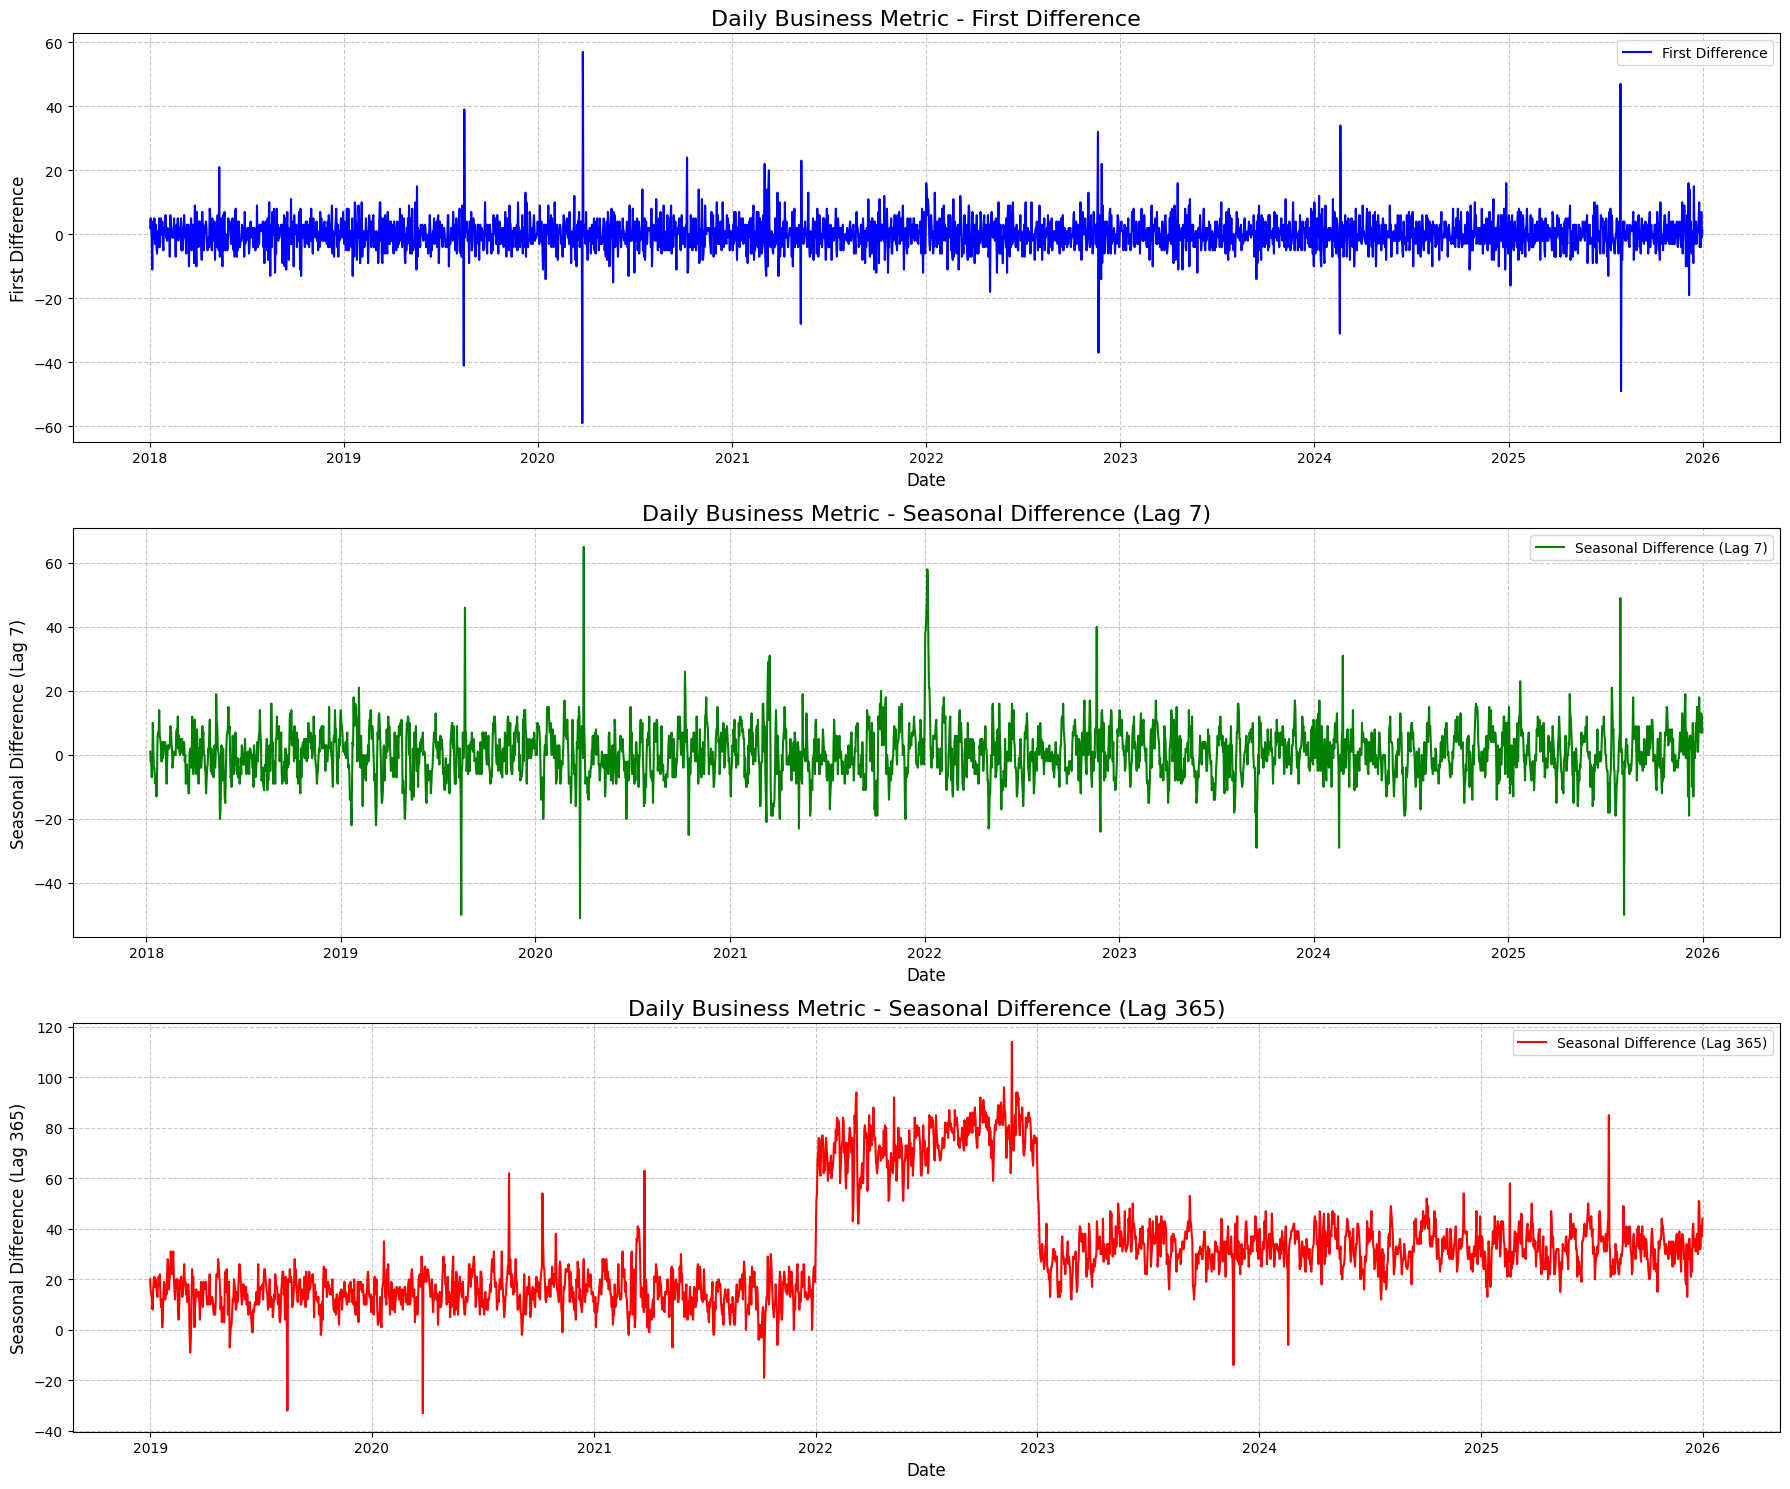


--- Stationarity Tests for First Difference ---

  --- Augmented Dickey-Fuller Test ---
  Test Statistic: -10.8310
  P-value: 0.0000
  Critical Values:
      1%: -3.4326
      5%: -2.8625
      10%: -2.5673
  Conclusion: The series is likely stationary (reject H0)

  --- KPSS Test ---
  Test Statistic: 0.0923
  P-value: 0.1000
  Critical Values:
      10%: 0.3470
      5%: 0.4630
      2.5%: 0.5740
      1%: 0.7390
  Conclusion: The series is likely stationary (fail to reject H0)

--- Stationarity Tests for Seasonal Difference (Lag 7) ---

  --- Augmented Dickey-Fuller Test ---


/tmp/ipykernel_1073/1749058133.py:71: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series_clean, regression='c', nlags='auto')


  Test Statistic: -7.7761
  P-value: 0.0000
  Critical Values:
      1%: -3.4326
      5%: -2.8625
      10%: -2.5673
  Conclusion: The series is likely stationary (reject H0)

  --- KPSS Test ---
  Test Statistic: 0.1599
  P-value: 0.1000
  Critical Values:
      10%: 0.3470
      5%: 0.4630
      2.5%: 0.5740
      1%: 0.7390
  Conclusion: The series is likely stationary (fail to reject H0)

--- Stationarity Tests for Seasonal Difference (Lag 365) ---

  --- Augmented Dickey-Fuller Test ---


/tmp/ipykernel_1073/1749058133.py:71: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series_clean, regression='c', nlags='auto')


  Test Statistic: -1.8323
  P-value: 0.3645
  Critical Values:
      1%: -3.4329
      5%: -2.8627
      10%: -2.5674
  Conclusion: The series is likely non-stationary (fail to reject H0)

  --- KPSS Test ---
  Test Statistic: 2.0684
  P-value: 0.0100
  Critical Values:
      10%: 0.3470
      5%: 0.4630
      2.5%: 0.5740
      1%: 0.7390
  Conclusion: The series is likely non-stationary (reject H0)


/tmp/ipykernel_1073/1749058133.py:71: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series_clean, regression='c', nlags='auto')


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np

# Apply first differencing
df['first_difference'] = df['daily_business_metric'].diff(1)

# Apply seasonal differencing (lag 7 for weekly seasonality)
df['seasonal_diff_7'] = df['daily_business_metric'].diff(7)

# Apply seasonal differencing (lag 365 for yearly seasonality)
df['seasonal_diff_365'] = df['daily_business_metric'].diff(365)

# --- Plotting Transformed Series ---
plt.figure(figsize=(18, 15))

plt.subplot(3, 1, 1)
plt.plot(df['first_difference'], label='First Difference', color='blue')
plt.title('Daily Business Metric - First Difference', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('First Difference', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['seasonal_diff_7'], label='Seasonal Difference (Lag 7)', color='green')
plt.title('Daily Business Metric - Seasonal Difference (Lag 7)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Seasonal Difference (Lag 7)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(df['seasonal_diff_365'], label='Seasonal Difference (Lag 365)', color='red')
plt.title('Daily Business Metric - Seasonal Difference (Lag 365)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Seasonal Difference (Lag 365)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# --- Rerunning ADF and KPSS tests on differenced series ---

def run_stationarity_tests(series, series_name):
    print(f"\n--- Stationarity Tests for {series_name} ---")
    # Drop NaN values introduced by differencing
    series_clean = series.dropna()

    if len(series_clean) == 0:
        print(f"Not enough data after differencing to run tests for {series_name}.")
        return

    # ADF Test
    print("\n  --- Augmented Dickey-Fuller Test ---")
    adf_test = adfuller(series_clean)
    print(f"  Test Statistic: {adf_test[0]:.4f}")
    print(f"  P-value: {adf_test[1]:.4f}")
    print("  Critical Values:")
    for key, value in adf_test[4].items():
        print(f"      {key}: {value:.4f}")
    if adf_test[1] <= 0.05:
        print("  Conclusion: The series is likely stationary (reject H0)")
    else:
        print("  Conclusion: The series is likely non-stationary (fail to reject H0)")

    # KPSS Test
    print("\n  --- KPSS Test ---")
    try:
        kpss_test = kpss(series_clean, regression='c', nlags='auto')
        print(f"  Test Statistic: {kpss_test[0]:.4f}")
        print(f"  P-value: {kpss_test[1]:.4f}")
        print("  Critical Values:")
        for key, value in kpss_test[3].items():
            print(f"      {key}: {value:.4f}")
        if kpss_test[1] <= 0.05:
            print("  Conclusion: The series is likely non-stationary (reject H0)")
        else:
            print("  Conclusion: The series is likely stationary (fail to reject H0)")
    except ValueError as e:
        print(f"  KPSS test could not be performed: {e}")
    except Exception as e:
        print(f"  An unexpected error occurred during KPSS test: {e}")


run_stationarity_tests(df['first_difference'], 'First Difference')
run_stationarity_tests(df['seasonal_diff_7'], 'Seasonal Difference (Lag 7)')
run_stationarity_tests(df['seasonal_diff_365'], 'Seasonal Difference (Lag 365)')

Generate Python code for Google Colab that plots ACF and PACF for both original and differenced series using statsmodels.


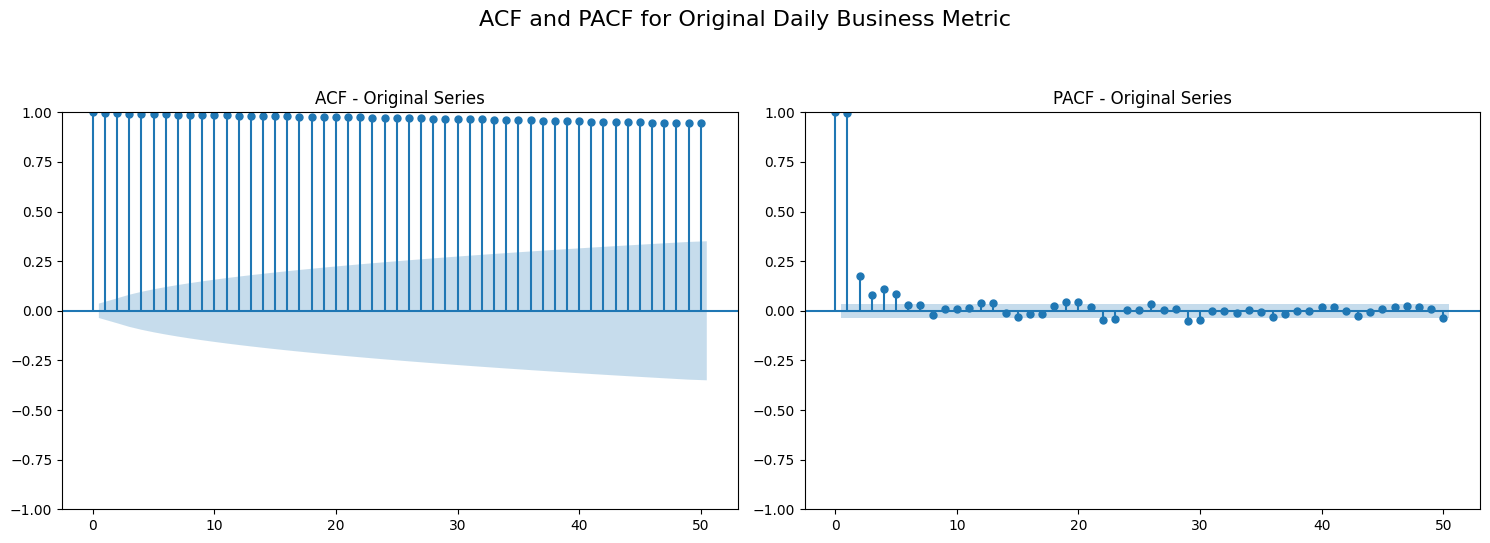

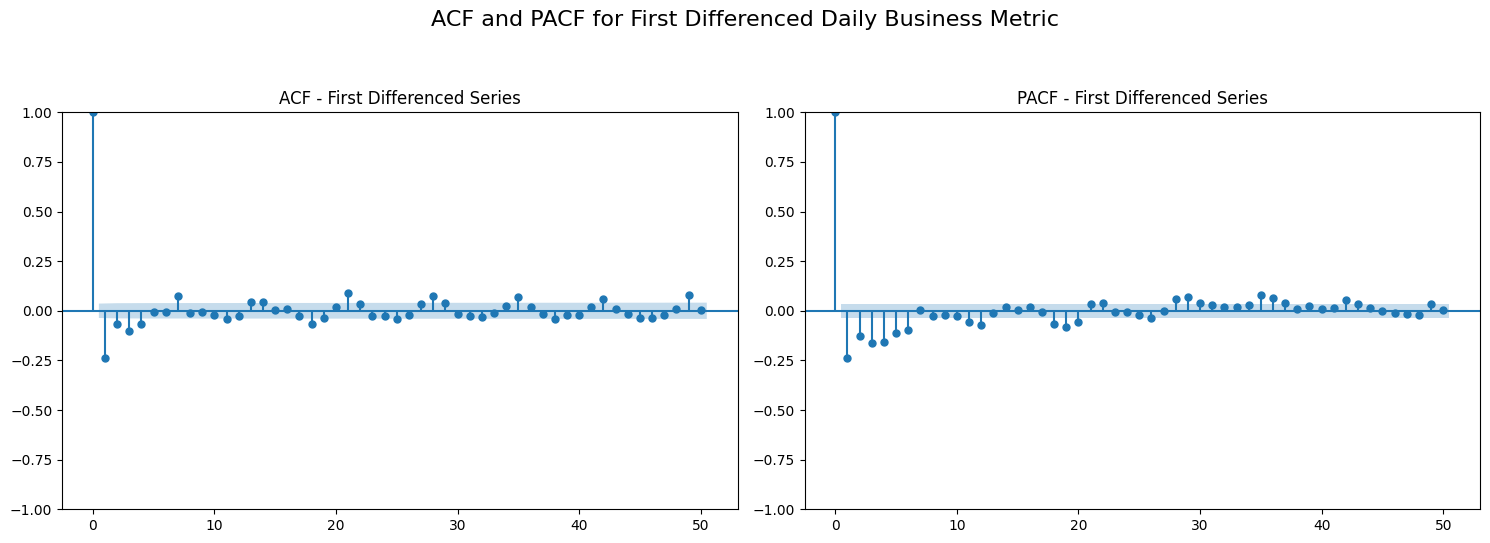

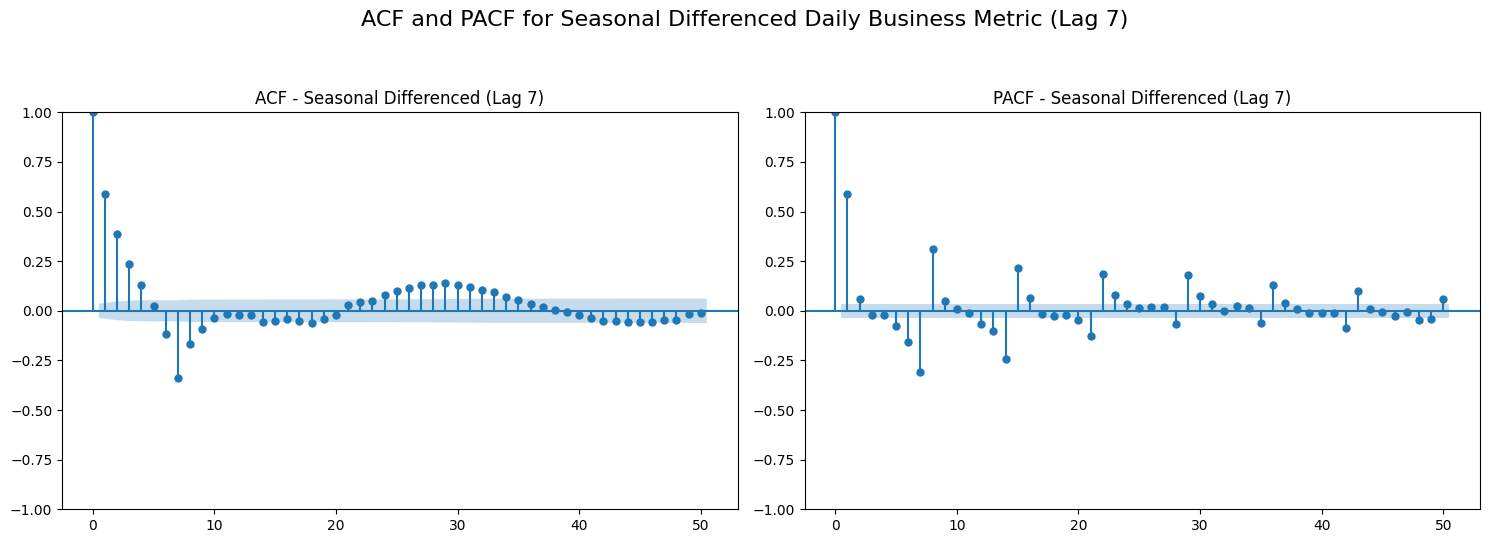

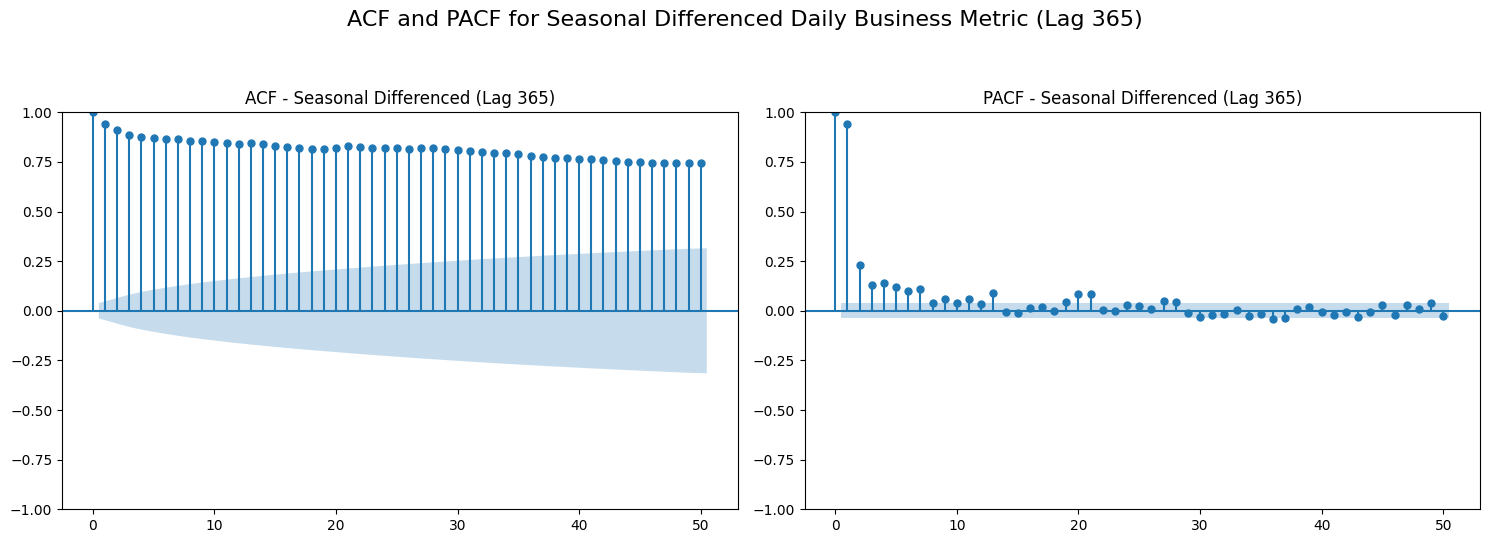

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- Plotting ACF and PACF for Original Series ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plot_acf(df['daily_business_metric'], lags=50, ax=plt.gca(), title='ACF - Original Series')

plt.subplot(2, 2, 2)
plot_pacf(df['daily_business_metric'], lags=50, ax=plt.gca(), title='PACF - Original Series')

plt.suptitle('ACF and PACF for Original Daily Business Metric', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Plotting ACF and PACF for First Differenced Series ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plot_acf(df['first_difference'].dropna(), lags=50, ax=plt.gca(), title='ACF - First Differenced Series')

plt.subplot(2, 2, 2)
plot_pacf(df['first_difference'].dropna(), lags=50, ax=plt.gca(), title='PACF - First Differenced Series')

plt.suptitle('ACF and PACF for First Differenced Daily Business Metric', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Plotting ACF and PACF for Seasonal Differenced (Lag 7) Series ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plot_acf(df['seasonal_diff_7'].dropna(), lags=50, ax=plt.gca(), title='ACF - Seasonal Differenced (Lag 7)')

plt.subplot(2, 2, 2)
plot_pacf(df['seasonal_diff_7'].dropna(), lags=50, ax=plt.gca(), title='PACF - Seasonal Differenced (Lag 7)')

plt.suptitle('ACF and PACF for Seasonal Differenced Daily Business Metric (Lag 7)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Plotting ACF and PACF for Seasonal Differenced (Lag 365) Series ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plot_acf(df['seasonal_diff_365'].dropna(), lags=50, ax=plt.gca(), title='ACF - Seasonal Differenced (Lag 365)')

plt.subplot(2, 2, 2)
plot_pacf(df['seasonal_diff_365'].dropna(), lags=50, ax=plt.gca(), title='PACF - Seasonal Differenced (Lag 365)')

plt.suptitle('ACF and PACF for Seasonal Differenced Daily Business Metric (Lag 365)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generate Python code for Google Colab that splits the dataset into train and test sets with the last 90 days as test data, fits an ARIMA model on training data, forecasts on test data, and plots actual vs predicted values.


Training set size: 2832
Test set size: 90
Test set start date: 2025-10-03
Test set end date: 2025-12-31

Fitting ARIMA model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                 
Dep. Variable:     daily_business_metric   No. Observations:                 2832
Model:                    ARIMA(5, 1, 0)   Log Likelihood               -8519.630
Date:                   Mon, 13 Apr 2026   AIC                          17051.260
Time:                           02:23:44   BIC                          17086.950
Sample:                       01-01-2018   HQIC                         17064.136
                            - 10-02-2025                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3278      0.007    -44.464      0.000      -0.342      -0.313
ar.L2         -0.2214      0.017    -13.205      0.000      -0.254      -0.189
ar.L3         -0.2237      0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


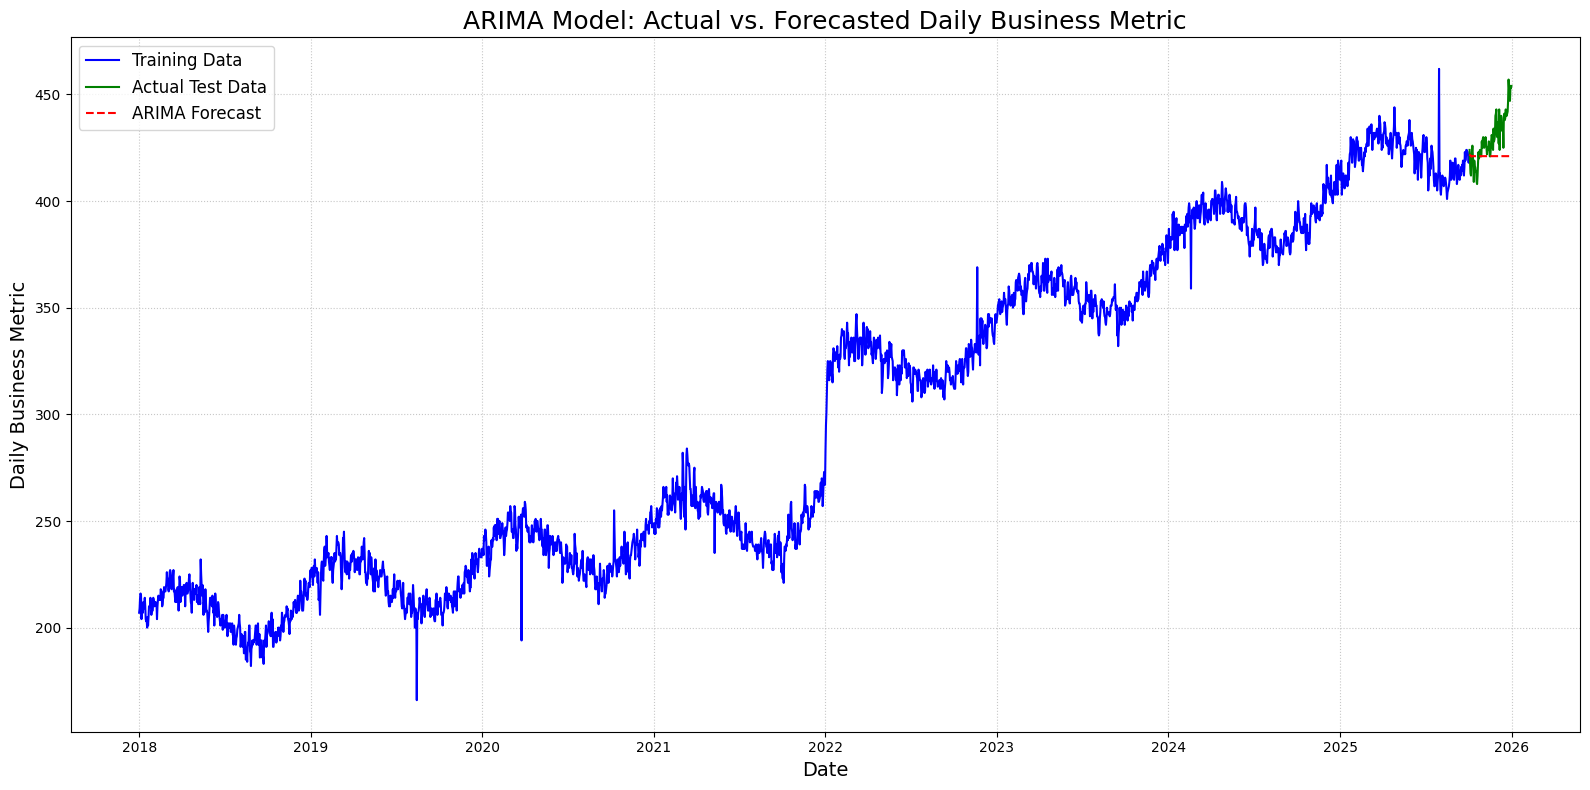

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Split the dataset into training and testing sets
# Last 90 days as test data

# Ensure the dataframe is sorted by date
df_sorted = df.sort_index()

test_size = 90
train = df_sorted['daily_business_metric'][:-test_size]
test = df_sorted['daily_business_metric'][-test_size:]

print(f"Training set size: {len(train)}")
print(f"Test set size: {len(test)}")
print(f"Test set start date: {test.index.min().strftime('%Y-%m-%d')}")
print(f"Test set end date: {test.index.max().strftime('%Y-%m-%d')}")

# Fit an ARIMA model on the training data
# Using (p,d,q) = (5,1,0) as a starting point based on previous analysis:
# d=1 because the first differenced series appeared stationary.
# p=5 because PACF of first differenced series showed significant spikes up to lag 5.
# q=0 for simplicity to start, as ACF of first differenced series tapered after a few lags.

print("\nFitting ARIMA model...")
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

# Forecast on the test data
# The 'start' and 'end' parameters for forecast should correspond to the test set indices.
forecast_start = test.index.min()
forecast_end = test.index.max()

predictions = model_fit.predict(start=forecast_start, end=forecast_end, typ='levels')

# Ensure predictions have the same index as the test set for easy plotting
predictions.index = test.index

# Evaluate the model
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(16, 8))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Test Data', color='green')
plt.plot(predictions.index, predictions, label='ARIMA Forecast', color='red', linestyle='--')

plt.title('ARIMA Model: Actual vs. Forecasted Daily Business Metric', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily Business Metric', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Generate Python code for Google Colab that uses pmdarima auto_arima to determine optimal parameters, fits the model, forecasts on test data, and plots predictions vs actuals.


Finding optimal ARIMA parameters using auto_arima...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[7]             : AIC=inf, Time=6.85 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=19097.772, Time=0.13 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=18175.819, Time=0.70 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=3.21 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=18932.295, Time=0.11 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=17760.372, Time=1.39 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=11.97 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=4.58 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=17973.899, Time=0.79 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=17707.825, Time=1.65 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=18120.346, Time=0.99 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=12.95 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=7.86 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=17665.845, Time=2.49 sec


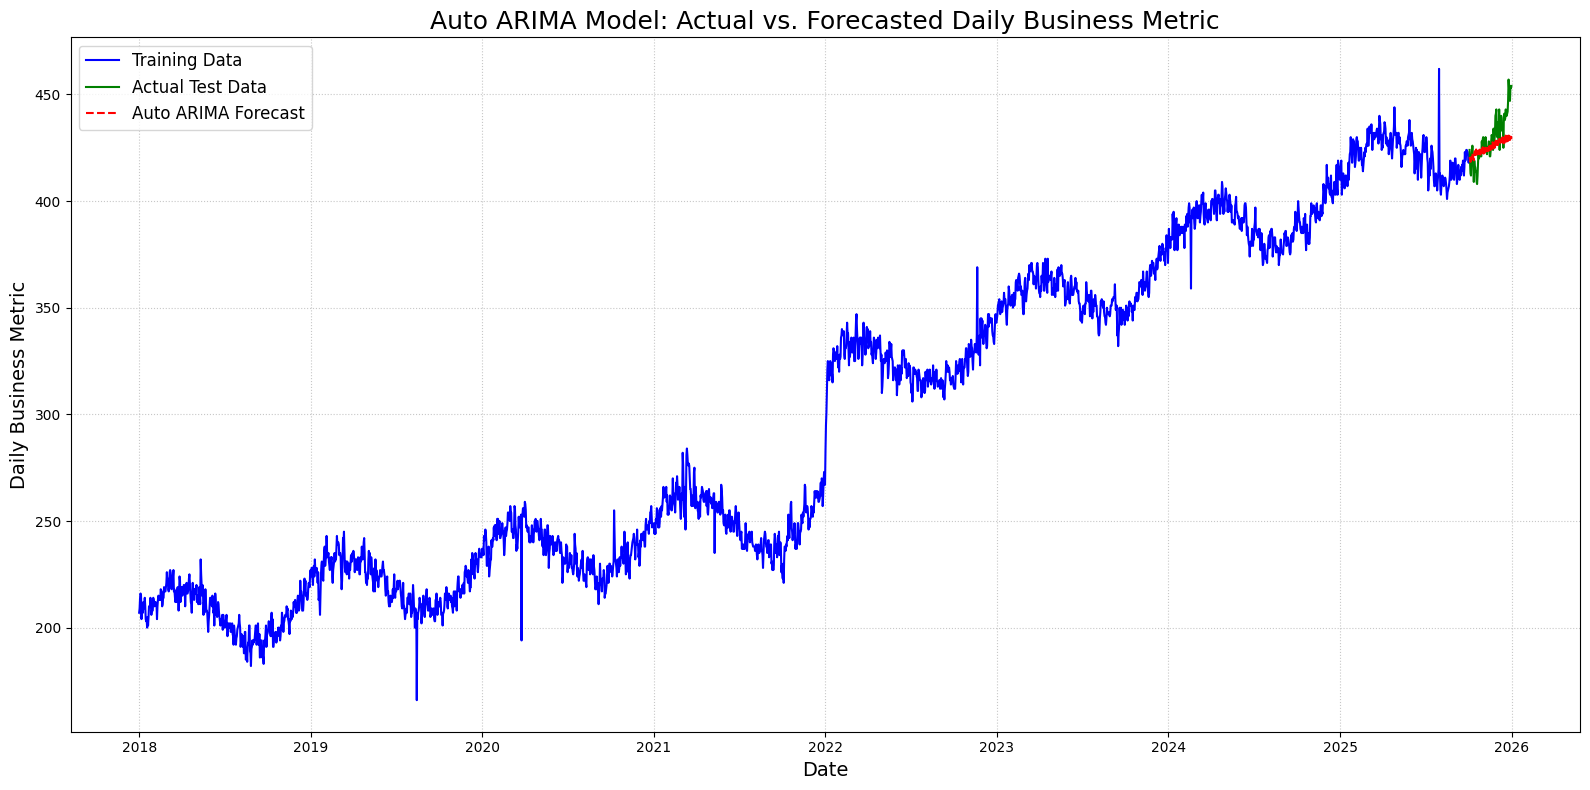

In [ ]:
import pmdarima as pm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# train and test data are already defined from the previous cell
# train = df_sorted['daily_business_metric'][:-test_size]
# test = df_sorted['daily_business_metric'][-test_size:]

print("Finding optimal ARIMA parameters using auto_arima...")
# Use auto_arima to find the best ARIMA model parameters
# seasonal=True indicates seasonal components should be considered
# m=7 for weekly seasonality (as data is daily)
# stepwise=True uses a faster algorithm to search for parameters
# suppress_warnings=True to keep the output clean
auto_model = pm.auto_arima(train, seasonal=True, m=7,
                           d=1, D=1, # Initial differencing estimates based on previous analysis
                           start_p=1, start_q=1,
                           max_p=5, max_q=5, max_d=2,
                           start_P=0, start_Q=0,
                           max_P=2, max_Q=2, max_D=1,
                           trace=True,  # Print out the search results
                           error_action='ignore',  # Don't stop if a model fails to converge
                           suppress_warnings=True,
                           stepwise=True)

print("\nOptimal ARIMA Model Summary:")
print(auto_model.summary())

# Forecast on the test data
print("\nForecasting on test data...")
forecast_steps = len(test)
forecast_auto = auto_model.predict(n_periods=forecast_steps)

# Ensure predictions have the same index as the test set for easy plotting
forecast_auto_series = pd.Series(forecast_auto, index=test.index)

# Evaluate the model
mae_auto = mean_absolute_error(test, forecast_auto_series)
mse_auto = mean_squared_error(test, forecast_auto_series)
rmse_auto = np.sqrt(mse_auto)

print(f"\nMean Absolute Error (MAE) [auto_arima]: {mae_auto:.2f}")
print(f"Mean Squared Error (MSE) [auto_arima]: {mse_auto:.2f}")
print(f"Root Mean Squared Error (RMSE) [auto_auto_arima]: {rmse_auto:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(16, 8))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Test Data', color='green')
plt.plot(forecast_auto_series.index, forecast_auto_series, label='Auto ARIMA Forecast', color='red', linestyle='--')

plt.title('Auto ARIMA Model: Actual vs. Forecasted Daily Business Metric', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily Business Metric', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Generate Python code for Google Colab that extracts residuals from the ARIMA model and plots residual time series, histogram, QQ plot, and performs Ljung-Box test.


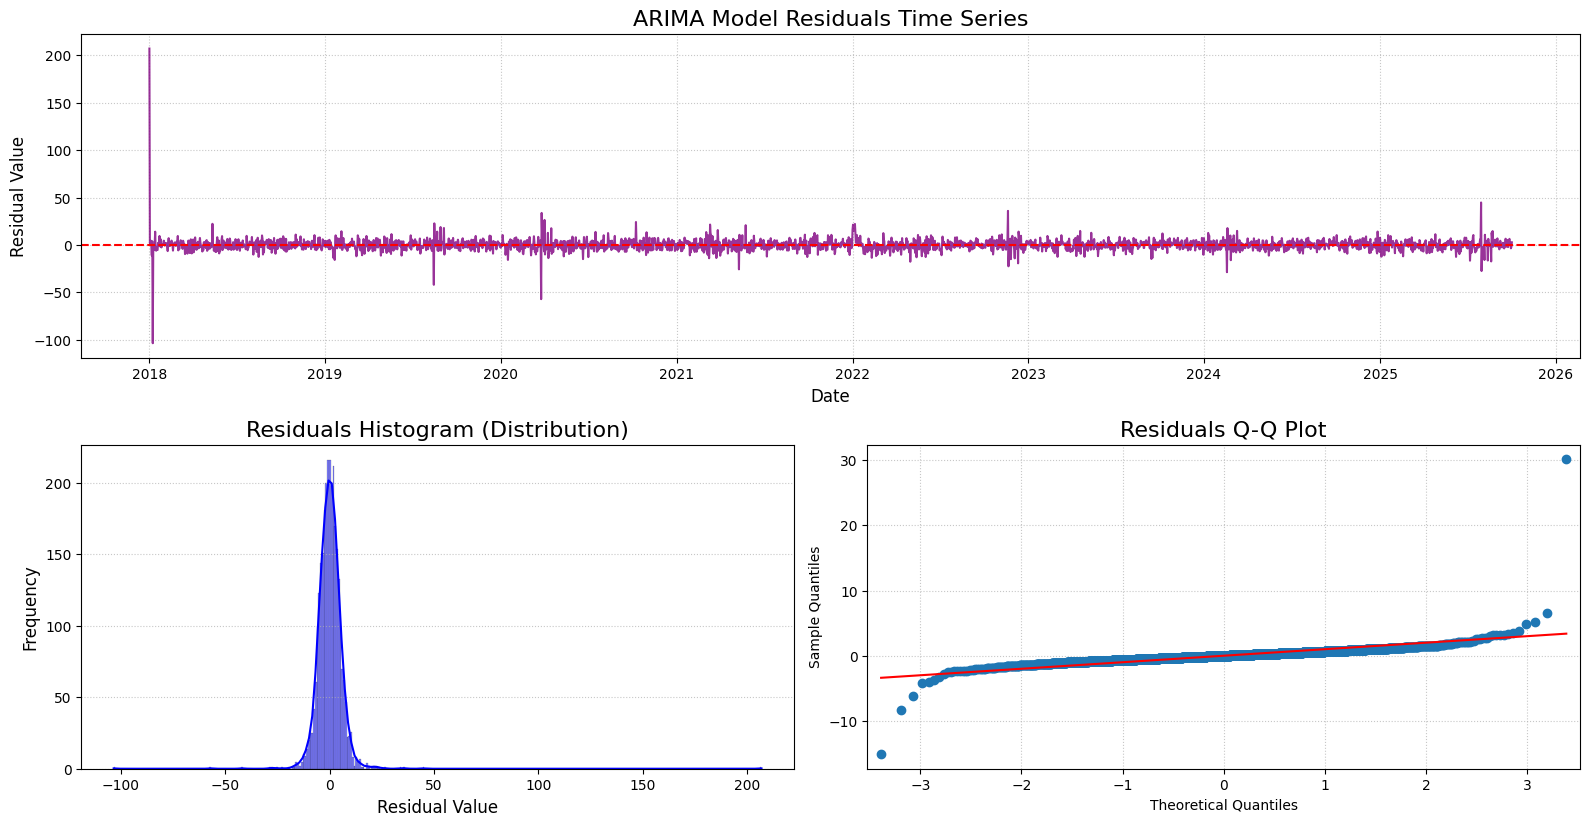


--- Ljung-Box Test on ARIMA Model Residuals ---
       lb_stat     lb_pvalue
1     0.016485  8.978357e-01
5     0.905373  9.698314e-01
10  126.830326  2.067886e-22
20  160.738810  5.406294e-24

Interpretation:
For lag 1: P-value = 0.8978. Residuals are independently distributed (Fail to reject H0).
For lag 5: P-value = 0.9698. Residuals are independently distributed (Fail to reject H0).
For lag 10: P-value = 0.0000. Residuals are not independently distributed (Reject H0) - possible autocorrelation.
For lag 20: P-value = 0.0000. Residuals are not independently distributed (Reject H0) - possible autocorrelation.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# Get residuals from the auto_arima model
residuals = auto_model.resid()

# --- Plot Residuals ---
plt.figure(figsize=(16, 12))

# Plot 1: Residuals Time Series Plot
plt.subplot(3, 1, 1)
plt.plot(residuals.index, residuals, color='purple', alpha=0.8)
plt.title('ARIMA Model Residuals Time Series', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual Value', fontsize=12)
plt.axhline(0, color='red', linestyle='--')
plt.grid(True, linestyle=':', alpha=0.7)

# Plot 2: Residuals Histogram
plt.subplot(3, 2, 3)
sns.histplot(residuals, kde=True, color='blue')
plt.title('Residuals Histogram (Distribution)', fontsize=16)
plt.xlabel('Residual Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Plot 3: Residuals QQ Plot
plt.subplot(3, 2, 4)
sm.qqplot(residuals, line='s', ax=plt.gca(), fit=True)
plt.title('Residuals Q-Q Plot', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# --- Perform Ljung-Box Test on Residuals ---
print("\n--- Ljung-Box Test on ARIMA Model Residuals ---")
# The Ljung-Box test checks for autocorrelation in the residuals. H0: residuals are independently distributed (white noise).
# lags: The number of lags to test.
# auto_arima summary output typically shows Ljung-Box up to lag 1.
# Let's test for a few more lags, e.g., 1, 5, 10, 20.

lags_to_test = [1, 5, 10, 20]
l_box_results = acorr_ljungbox(residuals, lags=lags_to_test, return_df=True)
print(l_box_results)

print("\nInterpretation:")
for lag in lags_to_test:
    p_value = l_box_results.loc[lag, 'lb_pvalue']
    if p_value > 0.05:
        print(f"For lag {lag}: P-value = {p_value:.4f}. Residuals are independently distributed (Fail to reject H0).")
    else:
        print(f"For lag {lag}: P-value = {p_value:.4f}. Residuals are not independently distributed (Reject H0) - possible autocorrelation.")


Generate Python code for Google Colab that fits ARIMA on the full dataset and generates future forecasts for the next 90 days and plots them along with historical data.


Fitting ARIMA model on the full dataset using optimal parameters...
Model fitted on full dataset. Summary:
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 2922
Model:             SARIMAX(1, 1, 2)x(2, 1, [], 7)   Log Likelihood               -9006.123
Date:                            Mon, 13 Apr 2026   AIC                          18026.246
Time:                                    03:01:29   BIC                          18068.087
Sample:                                01-01-2018   HQIC                         18041.319
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
interce

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['stepwise']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


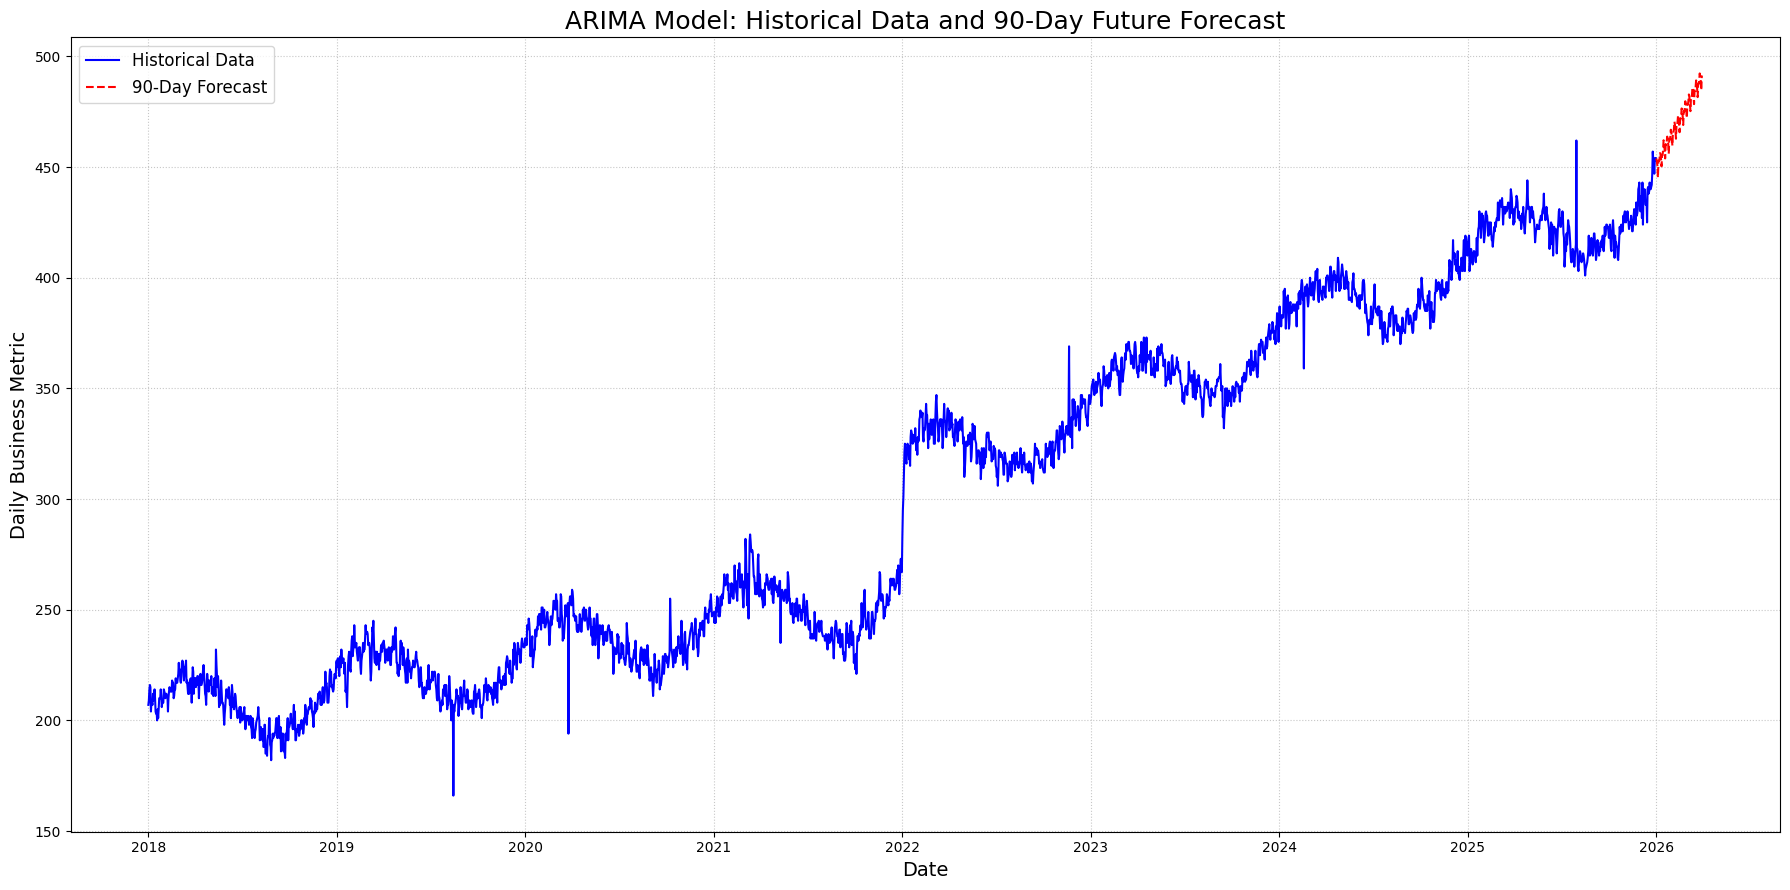

In [ ]:
import pmdarima as pm
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is the DataFrame with the full historical data
# and 'daily_business_metric' is the target series.
# Also assuming 'auto_model' from previous cell has determined optimal parameters.

print("Fitting ARIMA model on the full dataset using optimal parameters...")

# Re-fit the auto_arima model (or a pm.ARIMA model with the optimal order) on the entire dataset
# Using the order determined by auto_arima from the previous step
# In the previous run, auto_model.order was (1, 1, 2) and auto_model.seasonal_order was (2, 1, 0, 7)

# Extracting optimal order from the previously fitted auto_model
optimal_order = auto_model.order
optimal_seasonal_order = auto_model.seasonal_order

full_model = pm.ARIMA(order=optimal_order, seasonal_order=optimal_seasonal_order,
                      suppress_warnings=True, stepwise=True)
full_model.fit(df['daily_business_metric'])

print("Model fitted on full dataset. Summary:")
print(full_model.summary())

# Define the number of future days to forecast
forecast_horizon = 90

# Generate future dates for the forecast
last_date = df.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

# Generate future forecasts
print(f"\nGenerating {forecast_horizon}-day future forecasts...")
forecast_future = full_model.predict(n_periods=forecast_horizon)
forecast_future_series = pd.Series(forecast_future, index=future_dates)

# Plot historical data and future forecasts
plt.figure(figsize=(18, 9))

plt.plot(df.index, df['daily_business_metric'], label='Historical Data', color='blue')
plt.plot(forecast_future_series.index, forecast_future_series, label=f'{forecast_horizon}-Day Forecast', color='red', linestyle='--')

plt.title(f'ARIMA Model: Historical Data and {forecast_horizon}-Day Future Forecast', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily Business Metric', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()